# RPC metrics with a KSG (nearest-neighbour) mutual information estimator

This notebook is the counterpart of `calc_RPC.ipynb`. The pre-processing, the
variance-based RPC ($\rho$) and every figure are the same; the only thing that changes is
**how mutual information is estimated**.

| | `calc_RPC.ipynb` | this notebook |
|---|---|---|
| MI estimator | 2-D histogram, Freedman-Diaconis bins | KSG $k$-nearest-neighbour, rank/copula transform |
| ensemble handling | *jugaad* flattening: obs tiled $N\times$, members pooled into one 1-D sample | each time step is one sample, the $N$ members are $N$ **dimensions** |
| free parameter | bin count (varied $\times 0.5, 1, 1.5$) | neighbour count $k$ (varied $3, 5, 10$) |

Because the KSG estimator consumes the ensemble jointly rather than pooling members, two
parts of the published recipe have no literal translation. Both are spelled out in
"Three things that do not translate directly" below — read that before using the numbers.

**Runtime.** The full grid is $64\times128=8192$ points and every point needs its own
kd-trees, so a cold run is roughly 20 minutes. Results are cached to
`../data/ksg_rpc_cache.npz`; set `USE_CACHE = False` to force a recompute.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib import rc
import xarray as xr
import pandas as pd
from tqdm import tqdm
import warnings
import os
import cartopy.crs as ccrs
from scipy.stats import skew, kurtosis, rankdata, iqr
from scipy.spatial import cKDTree
from scipy.special import digamma, gamma
from numpy import nanmean, nanvar

In [2]:
# Setting the fonts for matplotlib
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

# uncomment to return fonts to default settings
# plt.rcdefaults()

# Pre-processing

Identical to `calc_RPC.ipynb` cell 3, with one guard: the observation file on disk now
carries a plain `datetime64` time axis rather than a `cftime` one, so
`obs.indexes["time"].to_datetimeindex()` raises `AttributeError`. The call is a no-op on a
`DatetimeIndex`, so it is applied only when the index actually needs converting; results
are bit-identical either way. `calc_RPC.ipynb` carries the same guard.

In [3]:
# Load in the datasets
f = xr.open_dataset("../data/ensembles/large_psl_decadal_ensemble_no_extrapolate.nc").drop_dims(["bnds"])
obs = xr.open_dataset("../data/obs/hadslp2/hadslp2_monthly_1850_2004.nc")
obs = obs.where(obs["time.year"]>=1962, drop=True)
obs = obs.where(obs["time.year"]<1972, drop=True)
obs = obs.sortby("lon")

# Interpolate the observations to match the model outputs
with warnings.catch_warnings(action="ignore"):
    # hasattr guard: no-op when the file already stores datetime64 rather than cftime
    idx = obs.indexes["time"]
    obs["time"] = idx.to_datetimeindex() if hasattr(idx, "to_datetimeindex") else idx
obs = obs.interp_like(f, kwargs={"fill_value":"extrapolate"})

# Linearly detrend the data
obs_lin_trend = xr.polyval(obs["time"], obs.psl.polyfit(dim='time', deg=1).polyfit_coefficients)
obs["psl"] = obs["psl"] - obs_lin_trend

f_lin_trend = xr.polyval(f["time"], f.psl.polyfit(dim='time', skipna=True, deg=1).polyfit_coefficients)
f["psl"] = f["psl"] - f_lin_trend

s = f.mean("n")

# Inspecting the Data

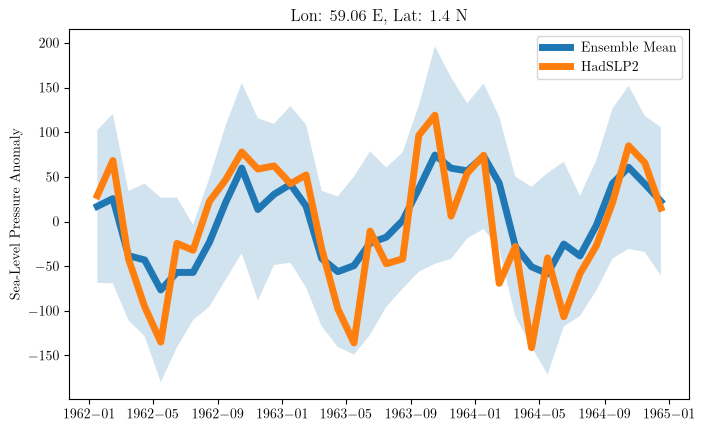

In [4]:
def inspect_data(lat_idx, lon_idx):
    lat, lon = lat_idx, lon_idx
    T_STOP = 36
    t = f.time.to_numpy().astype("datetime64[m]")
    t = t[:T_STOP]
    f_xy = f.isel(lat=lat, lon=lon).psl.to_numpy()
    f_xy = f_xy[:,:T_STOP]
    s_xy = np.mean(f_xy, axis=0)
    model_spread = np.std(f_xy, axis=0)
    g_xy = obs.isel(lat=lat, lon=lon).psl.to_numpy()
    g_xy = g_xy[:T_STOP]

    fig = plt.figure()
    plt.plot(t, s_xy, linewidth=5, label='Ensemble Mean')
    plt.fill_between(t, s_xy-model_spread, s_xy+model_spread, interpolate=True, alpha=0.2)
    plt.plot(t, g_xy, linewidth=5, label='HadSLP2')
    plt.legend()
    plt.ylabel("Sea-Level Pressure Anomaly")
    fig.set_figwidth(8)

    plt.title(f"Lon: {np.round(f.lon[lon].to_numpy(), 2)} E, Lat: {np.round(f.lat[lat].to_numpy(), 2)} N")
inspect_data(32, 21)

# Make histograms of the climate model outputs and the observation data

In [5]:
# flatten the data in order to make the histograms
flat_s = s.psl.to_numpy().flatten()
flat_obs = obs.psl.to_numpy().flatten()
flat_obs = flat_obs[~np.isnan(flat_obs)]
flat_f = f.psl.to_numpy().flatten()
flat_s = flat_s[~np.isnan(flat_s)]
flat_obs = flat_obs[~np.isnan(flat_obs)]
flat_f = flat_f[~np.isnan(flat_f)]

s_bins, s_edges = np.histogram(flat_s, bins=100, density=True)
obs_bins, obs_edges = np.histogram(flat_obs, bins=100, density=True)
f_bins, f_edges = np.histogram(flat_f, bins=1000, density=True)

s_mean, s_var, s_skew, s_kurt = np.round(nanmean(flat_s), 3), np.round(nanvar(flat_s),3), np.round(skew(flat_s),3), np.round(kurtosis(flat_s),3)
obs_mean, obs_var, obs_skew, obs_kurt = np.round(nanmean(flat_obs), 3), np.round(nanvar(flat_obs),3), np.round(skew(flat_obs),3), np.round(kurtosis(flat_obs),3)
f_mean, f_var, f_skew, f_kurt = np.round(nanmean(flat_f), 3), np.round(nanvar(flat_f),3), np.round(skew(flat_f),3), np.round(kurtosis(flat_f),3)

Sig -- mean=0.063 | var=104400.226 | skew=-0.288 | kurt=2.588
Obs -- mean=-0.0 | var=155033.895 | skew=0.136 | kurt=2.27
Ens -- mean=-0.0 | var=260389.658 | skew=0.014 | kurt=1.661


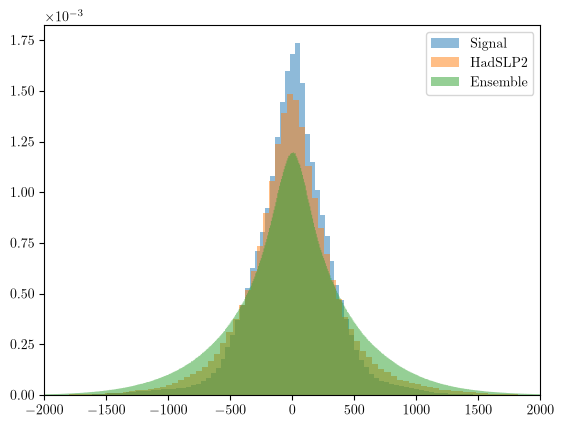

In [6]:
print(f"Sig -- mean={s_mean} | var={s_var} | skew={s_skew} | kurt={s_kurt}")
print(f"Obs -- mean={obs_mean} | var={obs_var} | skew={obs_skew} | kurt={obs_kurt}")
print(f"Ens -- mean={f_mean} | var={f_var} | skew={f_skew} | kurt={f_kurt}")

plt.stairs(s_bins, s_edges, fill=True, alpha=0.5, label='Signal')
plt.stairs(obs_bins, obs_edges, fill=True, alpha=0.5, label='HadSLP2')
plt.stairs(f_bins, f_edges, fill=True, alpha=0.5, label='Ensemble')
plt.legend()
plt.xlim([-2000, 2000])
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0));

# Estimate the RPC from the data

In [7]:
def var_RPC(ensemble:xr.Dataset, signal:xr.Dataset, observation:xr.Dataset):
    rho_o = xr.corr(signal.psl, observation.psl, dim="time")
    rho_o = xr.where(rho_o>0, rho_o, 0)
    var_s = signal.psl.var(dim="time", skipna=True)
    var_total = ensemble.psl.var(dim="time", skipna=True).mean("n")
    rho_m = np.sqrt(var_s / var_total)
    rho = rho_o/rho_m
    return rho_o, rho_m, rho
rho_o, rho_m, rho = var_RPC(f, s, obs)

/Users/jasperchen/Academics/Research/SNP/information-snp/.venv/lib/python3.13/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


# The KSG ensemble mutual information estimator

Estimates $I(F; g)$ where $F$ is the whole ensemble. Each **time step is one sample** and
the $N$ ensemble members are $N$ **dimensions**, so the estimator sees the joint ensemble
distribution instead of a pool of members. A rank/copula transform removes the marginals
first, then the Kraskov-Stogbauer-Grassberger $k$-NN identity gives $I$ in nats, converted
to bits. $\lambda = \sqrt{1 - 2^{-2I}}$ is returned alongside.

In [8]:
def ensemble_MI_KSG(f, g, k=5):
    """
    Estimate I(F; g) nonparametrically using the KSG estimator.

    Parameters
    ----------
    f : array, shape (N_members, T)
        Ensemble forecasts.
    g : array, shape (T,)
        Observations.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    I_bits : float
        Estimated mutual information in bits.
    lam : float
        lambda = sqrt(1 - 2^(-2 I)).
    """
    f = np.asarray(f, dtype=float)
    g = np.asarray(g, dtype=float)

    N, T = f.shape
    if g.shape != (T,):
        raise ValueError("g must have shape (T,) matching f.shape[1]")

    # Each time point is ONE sample; ensemble members are dimensions.
    X = f.T  # shape (T, N)

    # Copula/rank transform: removes marginal distributions
    X = np.column_stack([
        (rankdata(X[:, j]) - 0.5) / T
        for j in range(N)
    ])
    y = ((rankdata(g) - 0.5) / T)[:, None]

    # Joint variable (F, g)
    Z = np.column_stack([X, y])

    # Distance to kth neighbor in joint space, using max norm
    tree_Z = cKDTree(Z)
    distances, _ = tree_Z.query(Z, k=k + 1, p=np.inf)
    eps = np.nextafter(distances[:, k], 0)

    # Count neighbors within same radius in marginal spaces
    tree_X = cKDTree(X)
    tree_y = cKDTree(y)

    n_X = np.array([
        len(tree_X.query_ball_point(X[i], eps[i], p=np.inf)) - 1
        for i in range(T)
    ])

    n_y = np.array([
        len(tree_y.query_ball_point(y[i], eps[i], p=np.inf)) - 1
        for i in range(T)
    ])

    # KSG mutual information, initially in nats
    I_nats = (
        digamma(k)
        + digamma(T)
        - np.mean(digamma(n_X + 1) + digamma(n_y + 1))
    )

    I_bits = I_nats / np.log(2)

    # KSG can be slightly negative from sampling error
    I_for_lambda = max(0.0, I_bits)
    lam = np.sqrt(1.0 - 2.0 ** (-2.0 * I_for_lambda))

    return I_bits, lam

## The ensemble entropy, also nearest-neighbour

$H_f$ is the other place the jugaad trick was still in use: the published code pools all
$N\times T$ member values into one 1-D sample and takes a Freedman-Diaconis binned entropy.
The Kozachenko-Leonenko estimator below replaces it, again treating one time step as one
$N$-dimensional sample, so **the ensemble side of the calculation is now binning-free
end to end**.

Note what this changes about the quantity itself. The published $H_f$ was the *marginal*
entropy of a single member (bits, discrete, $\approx 4.7$). This is the *joint* differential
entropy of all $N$ members at once, $H(F_1,\dots,F_N)$, which at $N=49$ comes out around
$507$ bits. $H_g$ is untouched, so $\gamma_o$ and $\gamma_m$ are normalised by
quantities of very different dimensionality — consequences are quantified two cells below.

In [9]:
def ensemble_entropy(f, k=5):
    """
    Estimate the joint differential entropy H(F1,...,FN).

    Parameters
    ----------
    f : array, shape (N_members, T)
        Ensemble output.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    H_bits : float
        Joint differential entropy in bits.
    """
    f = np.asarray(f, dtype=float)

    # One time point = one multivariate sample
    X = f.T                      # shape (T, N_members)
    T, d = X.shape

    tree = cKDTree(X)

    # distance to kth nearest neighbor
    distances, _ = tree.query(X, k=k + 1, p=2)
    eps = distances[:, k]
    eps = np.maximum(eps, np.finfo(float).tiny)

    # volume of d-dimensional unit Euclidean ball
    c_d = np.pi**(d / 2) / gamma(d / 2 + 1)

    H_nats = (
        digamma(T)
        - digamma(k)
        + np.log(c_d)
        + d * np.mean(np.log(eps))
    )

    return H_nats / np.log(2)

## Three things that do not translate directly

**1. The model side cannot use the ensemble mean.** In `calc_RPC.ipynb` the model-side
information is `I_jugaad(s_t, f_t)`, the MI between the ensemble mean and a *randomly drawn
member*. Feeding the ensemble mean to a joint estimator instead asks for $I(F; s)$, and
$s$ is a deterministic function of $F$, so that quantity is infinite and the estimate just
reports the estimator's ceiling (measured: 0.23 bits at lat 32/lon 21 — indistinguishable
from the observed-side value, i.e. useless).

The perfect-model analogue is used instead: hold out member $i$, treat it as the
pseudo-observation, and feed the remaining $N-1$ members as the ensemble:
$$I_m = \big\langle\, I\big(F_{\setminus i};\, f_i\big) \,\big\rangle_i$$
averaged over `LOO_MEMBERS` held-out members. This is the direct information counterpart of
$\rho_m$ = correlation between the ensemble mean and a single member.

**2. $\gamma$'s two denominators are no longer the same kind of quantity.** The copula rank
transform inside `ensemble_MI_KSG` makes every marginal uniform, so the MI estimator itself
cannot supply an entropy to normalise by. The two denominators are now sourced differently:

* $H_f$ — the **Kozachenko-Leonenko joint differential entropy** of the ensemble,
  $H(F_1,\dots,F_N)$, from `ensemble_entropy` above. Binning-free, but 49-dimensional and
  $\approx 507$ bits.
* $H_g$ — still the **published Freedman-Diaconis binned** entropy of the tiled
  observations, $\approx 4.4$ bits, via helpers copied verbatim from
  `scripts/InfoTheoryMetrics.py`. There is only one observation series, so there is no
  ensemble dimension to apply a joint estimator to.

So $\gamma_o = I(F;g)/H_g$ divides by a 1-D discrete entropy while
$\gamma_m = \langle I(F_{\setminus i};f_i)\rangle/H_f$ divides by a 49-D differential
entropy. Their ratio is inflated by roughly a factor of $N$ relative to the published
$\gamma$: the same fields give $\gamma \approx 1.12$ under the published $H_f$ and
$\gamma \approx 121$ under the joint one. Set `H_F_PER_MEMBER = True` to divide $H_f$ by $N$,
which restores a per-member scale ($\gamma \approx 2.5$) and is the closest thing to a
like-for-like comparison. **$\lambda$ and $\rho$ need no entropy normalisation at all and
remain the metrics to compare against `calc_RPC.ipynb`.**

Two further properties of a differential entropy worth keeping in mind: it is not bounded
below by zero, and it is *scale-dependent* — rescaling the pressure units shifts $H_f$ by
$N\log_2(\text{scale})$, so 49 times more strongly than a 1-D entropy would move. The
published binned entropy had the same defect through its bin width, only 49 times weaker.

**3. NaNs hit a $k$-NN estimator harder than a histogram.** The ensemble is 2.84% NaN and
the pattern is structured, not random: members `n=10..19` (GFDL-CM2p1, decadal1961) cover
1961-01 to 1970-12 while every other model covers 1962-01 to 1971-12, so all of calendar
1971 is missing for those 10 members. The published code sets NaNs to 0.0, which under a
rank transform creates a block of tied coordinates.

`NANFILL` selects the behaviour:

* `"zero"` (default, matches published) — NaN $\to$ 0.0, all 8192 grid points defined.
* `"drop"` — drop any time step with a NaN in the ensemble or the observations. Retains 108
  of 120 time steps at a typical point, but longitude columns 0 and 127 are 20.7% and 42.9%
  NaN (wrap-around is not handled before `interp_like`), and those two columns retain
  **zero** usable time steps, so 128 grid points come back NaN.

The two choices differ by roughly 10% in $I$ at a typical grid point (0.187 vs 0.207 bits).

In [10]:
# --- copied verbatim from scripts/InfoTheoryMetrics.py so this notebook is self-contained ---
# (that module imports sklearn at top level, which is not installed in this environment)

def freedman_diaconis_bins(X):
    return int(np.ptp(X) / (2 * iqr(X) / np.power(len(X), 1/3)))

def prob_normalize(hist_counts):
    return hist_counts.astype(np.float32) / np.sum(hist_counts)

def I(X, Y, nbins_alt=None):
    """ Uses histograms to estimate the mutual information between two arrays of equal lengths. """
    N = len(X)
    if nbins_alt is None:
        XY_counts, _, _ = np.histogram2d(X,Y, bins=int(np.sqrt(N/5)))
    else:
        XY_counts, _, _ = np.histogram2d(X,Y, bins=nbins_alt)
    p_XY = prob_normalize(XY_counts)
    p_X = np.sum(p_XY, axis=1)
    p_Y = np.sum(p_XY, axis=0)
    p_XY = p_XY[np.where(p_XY > 0)]
    p_X = p_X[np.where(p_X>0)]
    p_Y = p_Y[np.where(p_Y>0)]
    H_X = -np.sum(p_X * np.log2(p_X))
    H_Y = -np.sum(p_Y * np.log2(p_Y))
    H_XY = -np.sum(p_XY * np.log2(p_XY))
    return H_X + H_Y - H_XY, H_X, H_Y

def I_jugaad(obs, model_output, nbins_alt=None):
    """ Uses the flattening trick described in the paper to calculate mutual information.
        obs: observation data of length L
        model_output: ensemble model output of size N x L
    """
    N,l = model_output.shape
    obs_jugaad = np.tile(obs, N)
    if type(model_output) is np.ndarray:
        return I(obs_jugaad, model_output.reshape(N*l), nbins_alt=nbins_alt)
    else:
        return I(obs_jugaad, model_output.to_numpy().reshape(N*l), nbins_alt=nbins_alt)

## Grid driver

`info_RPC_KSG` mirrors the return signature of `info_RPC`: four arrays of shape
`(len(KS), n_lat, n_lon)`. The leading axis is the neighbour count $k$ instead of the bin
multiplier, so index `1` is the default ($k=5$) exactly as index `1` was the default bin
count in `calc_RPC.ipynb`, and every downstream plotting cell carries over unchanged.

It also returns two permutation-null fields, `null_o` and `null_m`: the same estimator
applied after shuffling the target in time. That measures the estimator's bias floor at
each grid point, which is not negligible at $N=49$, $T=120$ (see the diagnostic section).

In [11]:
KS = (3, 5, 10)        # neighbour counts; index 1 (k=5) is the default used in the figures
NANFILL = "zero"       # "zero" matches the published code; "drop" removes incomplete steps
LOO_MEMBERS = 12       # held-out members averaged for the model side
N_PERM = 10            # permutations for the bias-floor null
MIN_T = 20             # give up on a grid point with fewer usable time steps than this
H_F_PER_MEMBER = False # divide the joint entropy H(F_1..F_N) by N to get a per-member scale


def info_RPC_KSG(ensemble:xr.Dataset, signal:xr.Dataset, observation:xr.Dataset,
                 ks=KS, nanfill=NANFILL, loo_members=LOO_MEMBERS,
                 n_perm=N_PERM, min_T=MIN_T, per_member=H_F_PER_MEMBER, seed=0):
    """
        KSG counterpart of InfoTheoryMetrics.info_RPC.

        Returns I_gf_mat, I_sf_mat, H_f_mat, H_g_mat each of shape (len(ks), n_lat, n_lon),
        plus null_o, null_m of shape (n_lat, n_lon) holding the permutation-null MI floor.

        I_gf: I(F; g)                     -- whole ensemble vs observations, KSG
        I_sf: <I(F_-i; f_i)>_i            -- leave-one-out perfect-model analogue, KSG
        H_f: H(F_1..F_N)                  -- Kozachenko-Leonenko joint differential entropy
        H_g: Freedman-Diaconis binned entropy of the tiled obs, as published
    """
    N, T, x_len, y_len = ensemble.psl.shape
    F = ensemble.psl.to_numpy()
    G = observation.psl.to_numpy()
    S = signal.psl.to_numpy()

    # evenly spaced held-out members, so both GFDL and non-GFDL models are represented
    held_out = np.unique(np.linspace(0, N - 1, loo_members).round().astype(int))
    rng = np.random.default_rng(seed)

    shape = (len(ks), x_len, y_len)
    I_gf_mat, I_sf_mat = np.full(shape, np.nan), np.full(shape, np.nan)
    H_f_mat, H_g_mat = np.full(shape, np.nan), np.full(shape, np.nan)
    null_o = np.full((x_len, y_len), np.nan)
    null_m = np.full((x_len, y_len), np.nan)

    for lat in tqdm(range(x_len), desc="Calculating KSG Entropy Metrics"):
        for lon in range(y_len):
            g_t = G[:, lat, lon]
            s_t = S[:, lat, lon]
            f_t = F[:, :, lat, lon].copy()

            # ---- H_g: published recipe (jugaad-tiled obs, FD bins) on the zero-filled ensemble.
            # There is only one observation series, so no joint estimator applies here.
            f_zero = f_t.copy()
            f_zero[np.where(np.isnan(f_zero))] = 0.0
            f_flat = f_zero.flatten()
            f_bins = freedman_diaconis_bins(f_flat)
            g_bins_ext = freedman_diaconis_bins(np.tile(np.nan_to_num(g_t, nan=0.0), N))
            _, H_g, _ = I_jugaad(np.nan_to_num(g_t, nan=0.0), f_zero,
                                 nbins_alt=(g_bins_ext, f_bins))
            H_g_mat[:, lat, lon] = H_g

            # ---- NaN policy for the KSG estimator
            if nanfill == "zero":
                f_use, g_use = f_zero, np.nan_to_num(g_t, nan=0.0)
            elif nanfill == "drop":
                keep = ~(np.isnan(f_t).any(axis=0) | np.isnan(g_t))
                f_use, g_use = f_t[:, keep], g_t[keep]
            else:
                raise ValueError(f"nanfill {nanfill} not recognized (use 'zero' or 'drop')")

            T_use = g_use.shape[0]
            if T_use < min_T or T_use <= max(ks) + 1:
                continue

            for j, k in enumerate(ks):
                I_gf_mat[j, lat, lon] = ensemble_MI_KSG(f_use, g_use, k=k)[0]
                I_sf_mat[j, lat, lon] = np.mean([
                    ensemble_MI_KSG(np.delete(f_use, i, axis=0), f_use[i], k=k)[0]
                    for i in held_out
                ])
                # H_f: Kozachenko-Leonenko joint differential entropy, no binning.
                # Unlike the published H_f this depends on k, so it varies along axis 0.
                H_f_mat[j, lat, lon] = ensemble_entropy(f_use, k=k) / (N if per_member else 1)

            # ---- permutation null at the default k, one held-out member for the model side
            k_def = ks[len(ks) // 2]
            i0 = held_out[len(held_out) // 2]
            null_o[lat, lon] = np.mean([
                ensemble_MI_KSG(f_use, rng.permutation(g_use), k=k_def)[0]
                for _ in range(n_perm)])
            null_m[lat, lon] = np.mean([
                ensemble_MI_KSG(np.delete(f_use, i0, axis=0), rng.permutation(f_use[i0]),
                                k=k_def)[0]
                for _ in range(n_perm)])

    return I_gf_mat, I_sf_mat, H_f_mat, H_g_mat, null_o, null_m

In [12]:
CACHE = "../data/ksg_rpc_cache.npz"
USE_CACHE = True   # set False to force a recompute (~20 min)

if USE_CACHE and os.path.exists(CACHE):
    _c = np.load(CACHE)
    I_fg, I_fs, H_f, H_g, null_o, null_m = (_c["I_fg"], _c["I_fs"], _c["H_f"],
                                            _c["H_g"], _c["null_o"], _c["null_m"])
    print("loaded cache", CACHE)
else:
    I_fg, I_fs, H_f, H_g, null_o, null_m = info_RPC_KSG(f, s, obs)
    np.savez_compressed(CACHE, I_fg=I_fg, I_fs=I_fs, H_f=H_f, H_g=H_g,
                        null_o=null_o, null_m=null_m, ks=np.array(KS))
    print("computed and cached to", CACHE)

print("shapes:", I_fg.shape, "| k values:", KS)
print("I(F;g)      k=5: mean %.4f  min %.4f  max %.4f bits" % (
    np.nanmean(I_fg[1]), np.nanmin(I_fg[1]), np.nanmax(I_fg[1])))
print("<I(F_-i;f_i)> k=5: mean %.4f  min %.4f  max %.4f bits" % (
    np.nanmean(I_fs[1]), np.nanmin(I_fs[1]), np.nanmax(I_fs[1])))
print("H_f  (KL joint)  k=5: mean %.2f  min %.2f  max %.2f bits" % (
    np.nanmean(H_f[1]), np.nanmin(H_f[1]), np.nanmax(H_f[1])))
print("H_g  (FD binned) k=5: mean %.3f  min %.3f  max %.3f bits" % (
    np.nanmean(H_g[1]), np.nanmin(H_g[1]), np.nanmax(H_g[1])))

loaded cache ../data/ksg_rpc_cache.npz
shapes: (3, 64, 128) | k values: (3, 5, 10)
I(F;g)      k=5: mean 0.3951  min 0.0333  max 1.8878 bits
<I(F_-i;f_i)> k=5: mean 0.3796  min 0.0712  max 1.8589 bits
H_f  (KL joint)  k=5: mean 507.51  min 392.35  max 576.92 bits
H_g  (FD binned) k=5: mean 4.366  min 3.203  max 4.954 bits


### What swapping $H_f$ does to $\gamma$

The joint entropy is roughly $N$ times larger than the per-member entropy it replaced, so
$\gamma_m$ shrinks by about that factor and $\gamma = \gamma_o/\gamma_m$ grows by it. The
cell below prints the three candidate normalisations side by side so the effect is explicit
rather than buried in the maps. $\lambda$ and $\rho$ are unaffected — neither divides by an
entropy.

In [13]:
_N = len(f.n)
_pub_H_f = 4.699   # grid-mean published FD-binned H_f, for reference only

_gam_o = np.nanmean(I_fg[1]) / np.nanmean(H_g[1])
_Hf_active = np.nanmean(H_f[1])
print("gamma_o = %.4f  (I(F;g) / H_g, both unchanged by this swap)" % _gam_o)
print("  [ratio of grid means; the maps below use the pointwise ratio, whose grid mean")
print("   is %.4f -- the two differ slightly because a mean of ratios is not the ratio" %
      np.nanmean(I_fg[1] / H_g[1]))
print("   of means. Same convention applies to every number in the table.]")
print()
print("H_f normalisation         grid-mean H_f      gamma_m    gamma = gamma_o/gamma_m")
for _label, _Hf in [("KL joint H(F_1..F_N)", _Hf_active if not H_F_PER_MEMBER else _Hf_active * _N),
                    ("KL joint / N", (_Hf_active / _N) if not H_F_PER_MEMBER else _Hf_active),
                    ("published FD-binned", _pub_H_f)]:
    _gm = np.nanmean(I_fs[1]) / _Hf
    print("  %-22s %12.2f  %11.3e  %12.2f" % (_label, _Hf, _gm, _gam_o / _gm))
print()
print("Currently active: %s (H_F_PER_MEMBER = %s)" % (
    "KL joint / N" if H_F_PER_MEMBER else "KL joint H(F_1..F_N)", H_F_PER_MEMBER))
print("A differential entropy can be negative; H_f < 0 at %d of %d grid points."
      % (int(np.nansum(H_f[1] < 0)), H_f[1].size))

gamma_o = 0.0905  (I(F;g) / H_g, both unchanged by this swap)
  [ratio of grid means; the maps below use the pointwise ratio, whose grid mean
   is 0.0958 -- the two differ slightly because a mean of ratios is not the ratio
   of means. Same convention applies to every number in the table.]

H_f normalisation         grid-mean H_f      gamma_m    gamma = gamma_o/gamma_m
  KL joint H(F_1..F_N)         507.51    7.480e-04        120.98
  KL joint / N                  10.36    3.665e-02          2.47
  published FD-binned            4.70    8.079e-02          1.12

Currently active: KL joint H(F_1..F_N) (H_F_PER_MEMBER = False)
A differential entropy can be negative; H_f < 0 at 0 of 8192 grid points.


## Metrics

Same algebra as `calc_RPC.ipynb`, with one necessary change: KSG estimates can come out
slightly negative from sampling error, and $\sqrt{1-2^{-2I}}$ is undefined for $I<0$. The
MI is clipped at zero before forming $\lambda$, exactly as `ensemble_MI_KSG` does
internally for its own returned `lam`.

In [14]:
# Calculate the different metrics from the estimated mutual informations
gam_o = I_fg / H_g
gam_m = I_fs / H_f
gam = gam_o / gam_m

# clip at 0 before the lambda transform (KSG can return small negative values)
lam_o = np.sqrt(1 - np.power(2., -2 * np.maximum(I_fg, 0.0)))
lam_m = np.sqrt(1 - np.power(2., -2 * np.maximum(I_fs, 0.0)))
lam = lam_o/lam_m

## Plot the metrics over the surface

Max lambda=1.494, Max rho=2.357


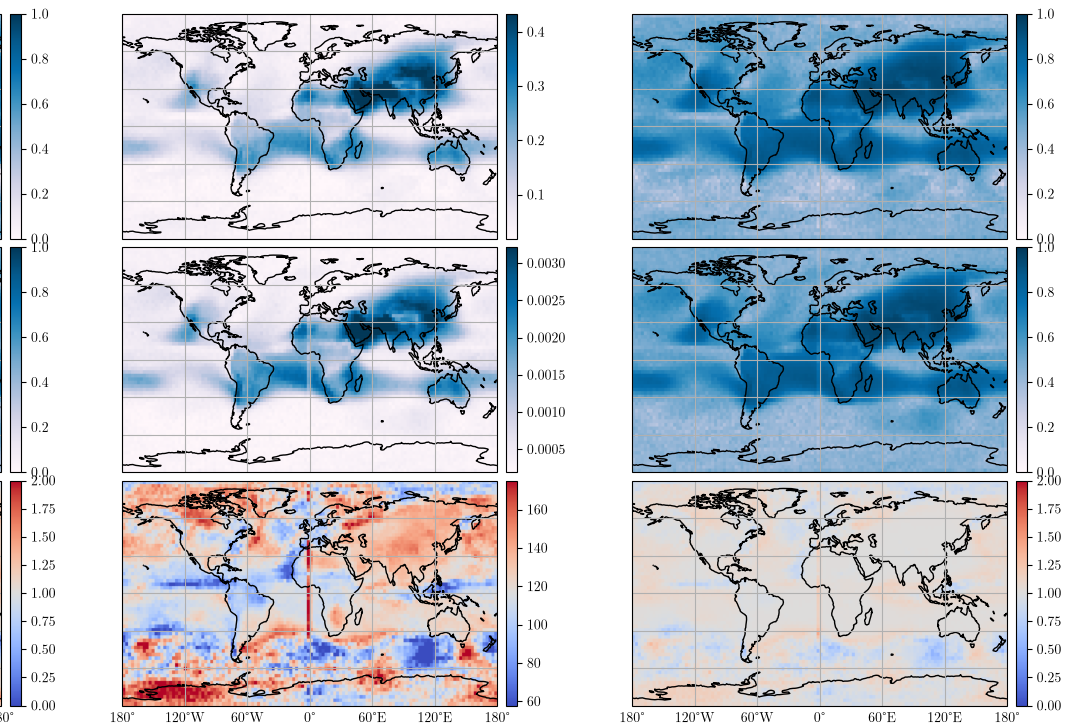

In [15]:
# layout='constrained' is needed once each panel carries its own colorbar -- without a
# layout engine the per-panel colorbars push the first column off the canvas. (Note this is
# the constrained engine, NOT tight_layout, which clashes with labelled cartopy gridlines.)
fig, axs = plt.subplots(3,3, subplot_kw=dict(projection=ccrs.PlateCarree()),
                        figsize=(15,7), layout='constrained')
_asp = 1.2
cmap = plt.colormaps['PuBu']
cmap2 = plt.colormaps['coolwarm']
PLOT_KWARGS = {"aspect": _asp,
               "origin":"lower",
               "extent":(0, 360, -90, 90),
               "cmap":cmap,
               "transform":ccrs.PlateCarree()
               }

PLOT_KWARGS2 = {"aspect": _asp,
               "origin":"lower",
               "extent":(0, 360, -90, 90),
               "cmap":cmap2,
               "transform":ccrs.PlateCarree()
               }

CBAR_KWARGS = {'fraction':0.030, 'pad':0.02}
# Every panel gets its own colorbar. The published version shared one colour scale per row,
# which worked when all three metrics were bounded by 1; it no longer does, because H_f is a
# 49-dimensional differential entropy and so gamma_m ~ 1e-3 while gamma ~ 1e2. rho and
# lambda keep the published fixed ranges (0-1, and 0-2 for the ratio); the gamma column is
# scaled to its own 1st-99th percentile rather than saturating to a solid block.
_n01, _n02 = Normalize(0, 1), Normalize(0, 2)


def _panel(ax, field, cmap_, norm):
    kw = {**PLOT_KWARGS, 'cmap': cmap_}
    _im = ax.imshow(field, norm=norm, **kw)
    fig.colorbar(_im, ax=ax, **CBAR_KWARGS)


def _pnorm(field):
    return Normalize(np.nanpercentile(field, 1), np.nanpercentile(field, 99))


_panel(axs[0,0], rho_o, cmap, _n01)
_panel(axs[0,1], gam_o[1], cmap, _pnorm(gam_o[1]))
_panel(axs[0,2], lam_o[1], cmap, _n01)

_panel(axs[1,0], rho_m, cmap, _n01)
_panel(axs[1,1], gam_m[1], cmap, _pnorm(gam_m[1]))
_panel(axs[1,2], lam_m[1], cmap, _n01)

_panel(axs[2,0], rho, cmap2, _n02)
_panel(axs[2,1], gam[1], cmap2, _pnorm(gam[1]))
_panel(axs[2,2], lam[1], cmap2, _n02)

print(f"Max lambda={np.round(np.nanmax(lam),3)}, Max rho={np.round(np.nanmax(rho),3)}")

PLOT_TITLES = np.array([
    [r"(a) $\rho_o$", r"(b) $\gamma_o$", r"(c) $\lambda_o$"],
    [r"(d) $\rho_m$", r"(e) $\gamma_m$", r"(f) $\lambda_m$"],
    [r"(g) $\rho$", r"(h) $\gamma$", r"(i) $\lambda$"]
])
m,n = axs.shape
for i in range(m):
    for j in range(n):
        axs[i,j].coastlines()
        gl = axs[i,j].gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False
        if j>=1:
            gl.left_labels=False
        if i<=1:
            gl.bottom_labels=False

        axs[i,j].set_title(PLOT_TITLES[i,j])

In [16]:
print("GAM_O AND GAM_M")
print("MAX:", np.nanmax(gam_o[1].flatten()), np.nanmax(gam_m[1].flatten()))
print("MEAN:", np.nanmean(gam_o[1].flatten()), np.nanmean(gam_m[1].flatten()))

print("LAM_O AND LAM_M")
print("MAX:", np.nanmax(lam_o[1].flatten()), np.nanmax(lam_m[1].flatten()))
print("MEAN:", np.nanmean(lam_o[1].flatten()), np.nanmean(lam_m[1].flatten()))

print("RPC ratios (grid mean):")
print("  rho   =", float(rho.mean(skipna=True)))
print("  gamma =", np.nanmean(gam[1]))
print("  lambda=", np.nanmean(lam[1]))


def frac_over_one(x, weighted=True):
    # Fraction of the surface where RPC > 1, cos(lat)-weighted over finite grid points.
    # The published figures are area-weighted: rho comes out at 72.1% weighted and only
    # 66.4% unweighted, and 72.1% is the published number, which fixes the convention.
    x = np.asarray(x, dtype=float)
    w = np.cos(np.deg2rad(f.lat.to_numpy()))[:, None] * np.ones((1, x.shape[1]))
    m = np.isfinite(x)
    if not weighted:
        return 100.0 * np.mean(x[m] > 1)
    return 100.0 * np.sum(w[m] * (x[m] > 1)) / np.sum(w[m])

print()
print("Surface area with RPC > 1, cos(lat)-weighted (published histogram run:"
      " rho 72.1%, gamma 18.9%, lambda 2.0%):")
for name, arr in [("rho", rho.to_numpy()), ("gamma", gam[1]), ("lambda", lam[1])]:
    print("  %-7s %5.1f%%   (unweighted %5.1f%%)" % (
        name, frac_over_one(arr), frac_over_one(arr, weighted=False)))

GAM_O AND GAM_M
MAX: 0.5342526268605179 0.003982627603916908
MEAN: 0.09579296902122987 0.0007863590001716675
LAM_O AND LAM_M
MAX: 0.9627982496535188 0.9612451583163681
MEAN: 0.5842414142350199 0.577865062115504
RPC ratios (grid mean):
  rho   = 1.0137701661969287
  gamma = 120.98517831718655
  lambda= 1.0107757403377688

Surface area with RPC > 1, cos(lat)-weighted (published histogram run: rho 72.1%, gamma 18.9%, lambda 2.0%):
  rho      72.1%   (unweighted  66.4%)
  gamma   100.0%   (unweighted 100.0%)
  lambda   73.6%   (unweighted  69.0%)


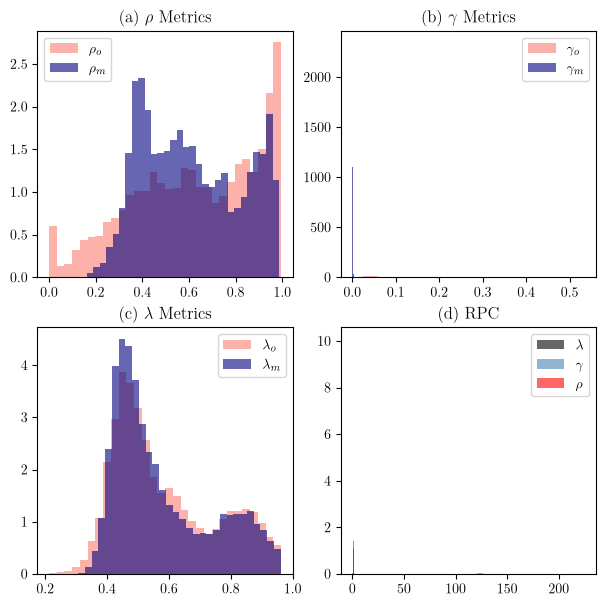

In [17]:
fig, axs = plt.subplots(2,2, figsize=(6,6))
axs[0,0].hist(rho_o.to_numpy().flatten(), alpha=0.6, bins=30, label="$\\rho_o$", color='salmon', density=True)
axs[0,0].hist(rho_m.to_numpy().flatten(), alpha=0.6, bins=30, label="$\\rho_m$", color='navy', density=True)
axs[0,0].legend()
axs[0,0].set_title(r"(a) $\rho$ Metrics")

axs[0,1].hist(gam_o[1].flatten(), alpha=0.6, bins=30, label=r"$\gamma_o$", color='salmon', density=True)
axs[0,1].hist(gam_m[1].flatten(), alpha=0.6, bins=30, label=r"$\gamma_m$", color='navy', density=True)
axs[0,1].set_title(r"(b) $\gamma$ Metrics ")
axs[0,1].legend()

axs[1,0].hist(lam_o[1].flatten(), alpha=0.6, bins=30, label=r"$\lambda_o$", color='salmon', density=True)
axs[1,0].hist(lam_m[1].flatten(), alpha=0.6, bins=30, color='navy', label=r"$\lambda_m$", density=True)
axs[1,0].set_title(r"(c) $\lambda$ Metrics")
axs[1,0].legend()

axs[1,1].hist(lam[1].flatten(), alpha=0.6, bins=30, label=r"$\lambda$", color='black', density=True)
axs[1,1].hist(gam[1].flatten(), alpha=0.6, bins=30, label=r"$\gamma$", color='steelblue', density=True)
axs[1,1].hist(rho.to_numpy().flatten(), alpha=0.6, bins=30, color='red', label="$\\rho$", density=True)
axs[1,1].set_title("(d) RPC")
axs[1,1].legend()

plt.tight_layout(pad=0.5)

# Quantifying $k$ sensitivity

The analogue of the binning-uncertainty section in `calc_RPC.ipynb`. There the spread came
from scaling the Freedman-Diaconis bin count by $0.5$ and $1.5$; here it comes from the
extreme neighbour counts, $k=3$ and $k=10$. As in the published notebook the two longitude
edge columns are patched from their neighbours, because wrap-around is not handled before
`interp_like` and they carry 20.7% and 42.9% NaN.

In [18]:
gam_o_range = np.abs(gam_o[2,:,:] - gam_o[0,:,:])
gam_m_range = np.abs(gam_m[2,:,:] - gam_m[0,:,:])
gam_o_range[:,0] = gam_o_range[:,1]
gam_o_range[:,-1] = gam_o_range[:,-2]
gam_m_range[:,0] = gam_m_range[:,1]
gam_m_range[:,-1] = gam_m_range[:,-2]

lam_o_range = np.abs(lam_o[2,:,:] - lam_o[0,:,:])
lam_m_range = np.abs(lam_m[2,:,:] - lam_m[0,:,:])
lam_o_range[:,0] = lam_o_range[:,1]
lam_o_range[:,-1] = lam_o_range[:,-2]
lam_m_range[:,0] = lam_m_range[:,1]
lam_m_range[:,-1] = lam_m_range[:,-2]

gam_range = np.abs(gam_o[2,:,:]/gam_m[2,:,:] - gam_o[0,:,:]/gam_m[0,:,:])
lam_range = np.abs(lam_o[2,:,:]/lam_m[2,:,:] - lam_o[0,:,:]/lam_m[0,:,:])
gam_range[:,0] = gam_range[:,1]
gam_range[:,-1] = gam_range[:,-2]
lam_range[:,0] = lam_range[:,1]
lam_range[:,-1] = lam_range[:,-2]

In [19]:
print("Mean gam k-sensitivity:", np.nanmean(gam_o_range), np.nanmean(gam_m_range), np.nanmean(gam_range))
print("Mean lambda k-sensitivity:", np.nanmean(lam_o_range), np.nanmean(lam_m_range), np.nanmean(lam_range))

Mean gam k-sensitivity: 0.025878129953382435 0.0002197271989161461 8.859393284480369
Mean lambda k-sensitivity: 0.06631119331947917 0.06587328875768184 0.03283349843565269


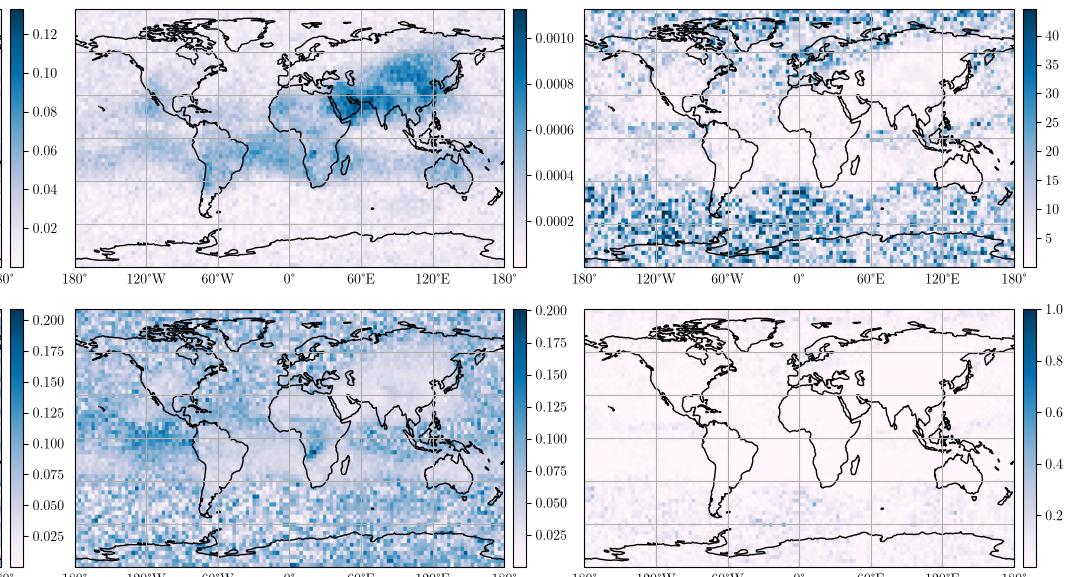

In [20]:
cmap = plt.colormaps['PuBu']
PLOT_KWARGS = {"aspect": 1.2,
               "origin":"lower",
               "extent":(0, 360, -90, 90),
               "cmap":cmap,
               "transform":ccrs.PlateCarree()
               }

fig, axs = plt.subplots(2,3, subplot_kw=dict(projection=ccrs.PlateCarree()),
                        figsize=(15,6), layout='constrained')
settings = {"fraction":0.030, "pad":0.02}
im0 = axs[0,0].imshow(gam_o_range, vmax=np.nanmax(gam_o_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im0, ax=axs[0,0], **settings)
im1 = axs[0,1].imshow(gam_m_range, vmax=np.nanmax(gam_m_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im1, ax=axs[0,1], **settings)
# gamma's scale is set by the 49-D H_f, so its k-sensitivity is O(10) rather than O(1);
# a hard vmax=1.0 (as in the published cell) would saturate this panel completely.
im2 = axs[0,2].imshow(gam_range, vmax=np.nanpercentile(gam_range, 99), **PLOT_KWARGS)
plt.colorbar(im2, ax=axs[0,2], **settings)

im3 = axs[1,0].imshow(lam_o_range, vmax=np.nanmax(lam_o_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im3, ax=axs[1,0], **settings)
im4 = axs[1,1].imshow(lam_m_range, vmax=np.nanmax(lam_m_range.flatten()), **PLOT_KWARGS)
plt.colorbar(im4, ax=axs[1,1], **settings)
im5 = axs[1,2].imshow(lam_range, vmax=1.0, **PLOT_KWARGS)
plt.colorbar(im5, ax=axs[1,2], **settings)

PLOT_TITLES = [
    [r"(a) $k$-sens. $\gamma_o$", r"(b) $k$-sens. $\gamma_m$", r"(c) $k$-sens. $\gamma$"],
    [r"(d) $k$-sens. $\lambda_o$", r"(e) $k$-sens. $\lambda_m$", r"(f) $k$-sens. $\lambda$"],
]
for i in range(2):
    for j in range(3):
        axs[i,j].coastlines()
        gl = axs[i,j].gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False
        if j>=1:
            gl.left_labels = False

        axs[i,j].set_title(PLOT_TITLES[i][j])

# NOTE: plt.tight_layout() is avoided here. With cartopy 0.25 + shapely 2.1, combining
# tight_layout() with gridlines(draw_labels=True) raises
#   GEOSException: Points of LinearRing do not form a closed linestring
# at draw time (this is what kills cell 21 of calc_RPC.ipynb; its cell 15 survives only
# because it has labelled gridlines but no tight_layout). The constrained layout engine
# set in plt.subplots above does the same spacing job without triggering it.

In [21]:
print("Mean Observation k-sensitivity:", np.nanmean(gam_o_range))
print("Mean Model k-sensitivity:", np.nanmean(gam_m_range[np.where(gam_m_range<np.inf)]))
print("Mean gamma k-sensitivity:", np.nanmean(gam_range[np.where(gam_range<np.inf)]))

Mean Observation k-sensitivity: 0.025878129953382435
Mean Model k-sensitivity: 0.0002197271989161461
Mean gamma k-sensitivity: 8.859393284480369


# The bias floor: how much of this is real?

A KSG estimator in $N+1$ dimensions with $T$ samples is biased upward, and here
$N+1 = 50$ against $T = 120$ — deep in the under-sampled regime. `null_o` and `null_m`
hold the estimate obtained after shuffling the target in time, which destroys the
dependence while preserving every marginal and the tie structure left by the zero-filled
NaNs. Whatever the estimator returns there is floor, not signal.

Read the panels below before trusting any absolute $\lambda_o$ or $\lambda_m$ value. The
ratio $\lambda = \lambda_o/\lambda_m$ is the more robust quantity, because the floor is
similar on both sides and partially cancels.

In [22]:
frac_o = np.nanmean(null_o / I_fg[1])
frac_m = np.nanmean(null_m / I_fs[1])
print("Permutation-null floor, grid mean:")
print("  observed side: %.4f bits  (%.1f%% of I(F;g) = %.4f)" % (
    np.nanmean(null_o), 100*frac_o, np.nanmean(I_fg[1])))
print("  model side   : %.4f bits  (%.1f%% of <I(F_-i;f_i)> = %.4f)" % (
    np.nanmean(null_m), 100*frac_m, np.nanmean(I_fs[1])))
print("Grid points where I(F;g) does not exceed its own null: %d / %d" % (
    np.nansum(I_fg[1] <= null_o), I_fg[1].size))

# floor-subtracted metrics
I_fg_c = np.maximum(I_fg[1] - null_o, 0.0)
I_fs_c = np.maximum(I_fs[1] - null_m, 0.0)
lam_o_c = np.sqrt(1 - np.power(2., -2*I_fg_c))
lam_m_c = np.sqrt(1 - np.power(2., -2*I_fs_c))
# Where the model side fails to clear its own null, I_fs_c clips to 0, lambda_m_c is
# exactly 0 and the ratio is undefined. Mask those points instead of reporting inf.
n_undef = int(np.sum(lam_m_c == 0))
lam_c = np.where(lam_m_c > 0, lam_o_c / np.where(lam_m_c > 0, lam_m_c, 1.0), np.nan)
print()
print("lambda_o  raw %.3f -> floor-subtracted %.3f" % (np.nanmean(lam_o[1]), np.nanmean(lam_o_c)))
print("lambda_m  raw %.3f -> floor-subtracted %.3f" % (np.nanmean(lam_m[1]), np.nanmean(lam_m_c)))
print("lambda    raw %.3f -> floor-subtracted %.3f  (undefined at %d points where the"
      " model side is below its own null)" % (
          np.nanmean(lam[1]), np.nanmean(lam_c), n_undef))

# The area fractions printed earlier count every grid point, including those whose MI
# never clears its own null -- those inherit the bias floor rather than measuring signal.
# Restrict to points that clear the null on BOTH sides before quoting an area fraction.
clears = (I_fg[1] > null_o) & (I_fs[1] > null_m)
lam_sig = np.where(clears, lam[1], np.nan)
gam_sig = np.where(clears, gam[1], np.nan)
print()
print("Restricted to the %d of %d points clearing both nulls (%.1f%% of the grid):" % (
    int(clears.sum()), clears.size, 100 * clears.mean()))
print("  lambda area > 1: %.1f%%  (unrestricted %.1f%%)" % (
    frac_over_one(lam_sig), frac_over_one(lam[1])))
print("  gamma  area > 1: %.1f%%  (unrestricted %.1f%%)" % (
    frac_over_one(gam_sig), frac_over_one(gam[1])))

Permutation-null floor, grid mean:
  observed side: 0.0793 bits  (35.4% of I(F;g) = 0.3951)
  model side   : 0.0789 bits  (35.0% of <I(F_-i;f_i)> = 0.3796)
Grid points where I(F;g) does not exceed its own null: 113 / 8192

lambda_o  raw 0.584 -> floor-subtracted 0.494
lambda_m  raw 0.578 -> floor-subtracted 0.489
lambda    raw 1.011 -> floor-subtracted 1.017  (undefined at 9 points where the model side is below its own null)

Restricted to the 8070 of 8192 points clearing both nulls (98.5% of the grid):
  lambda area > 1: 74.6%  (unrestricted 73.6%)
  gamma  area > 1: 100.0%  (unrestricted 100.0%)


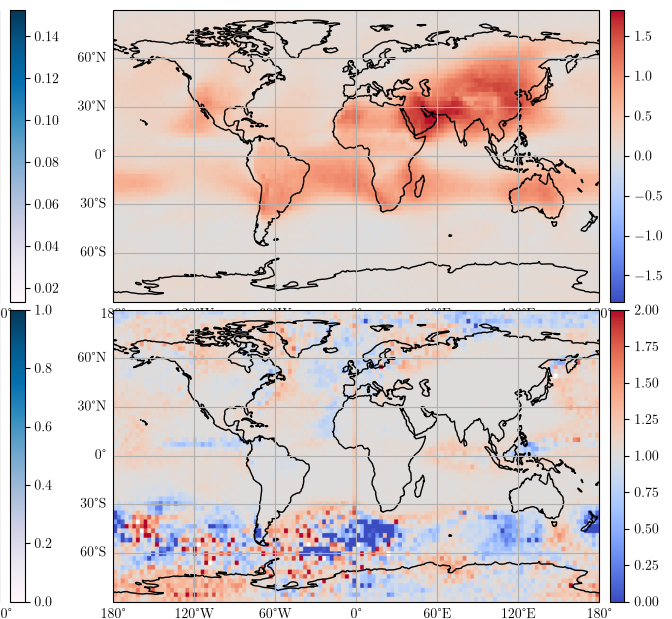

In [23]:
fig, axs = plt.subplots(2,2, subplot_kw=dict(projection=ccrs.PlateCarree()),
                        figsize=(12,6), layout='constrained')
PK = {"aspect":1.2, "origin":"lower", "extent":(0,360,-90,90), "transform":ccrs.PlateCarree()}
settings = {"fraction":0.030, "pad":0.02}

im0 = axs[0,0].imshow(null_o, cmap='PuBu', **PK)
plt.colorbar(im0, ax=axs[0,0], **settings)
axs[0,0].set_title(r"(a) null floor, observed side (bits)")

im1 = axs[0,1].imshow(I_fg[1] - null_o, cmap='coolwarm',
                      norm=Normalize(-np.nanmax(np.abs(I_fg[1]-null_o)),
                                      np.nanmax(np.abs(I_fg[1]-null_o))), **PK)
plt.colorbar(im1, ax=axs[0,1], **settings)
axs[0,1].set_title(r"(b) $I(F;g)$ above null (bits)")

im2 = axs[1,0].imshow(lam_o_c, cmap='PuBu', norm=Normalize(0,1), **PK)
plt.colorbar(im2, ax=axs[1,0], **settings)
axs[1,0].set_title(r"(c) $\lambda_o$, floor-subtracted")

im3 = axs[1,1].imshow(lam_c, cmap='coolwarm', norm=Normalize(0,2), **PK)
plt.colorbar(im3, ax=axs[1,1], **settings)
axs[1,1].set_title(r"(d) $\lambda$, floor-subtracted")

for a in axs.flatten():
    a.coastlines()
    gl = a.gridlines(draw_labels=True); gl.top_labels = False; gl.right_labels = False

# Summary of what changed, and what to trust

* **$\rho$ is untouched** — it never used mutual information, so it is bit-identical to
  `calc_RPC.ipynb` and is the anchor for comparing the two notebooks. It reproduces the
  published 72.1% of surface area with $\rho > 1$ exactly, which confirms the pre-processing
  here matches the published pipeline. (That match only appears under cos(lat) area
  weighting — unweighted the same field gives 66.4% — so the published percentages are
  area-weighted.)
* **$\lambda$ is the metric to compare.** It is bin-free on both sides, and the
  $\lambda_o/\lambda_m$ ratio cancels much of the estimator's bias floor.
* **The ensemble side is binning-free end to end** — KSG for the mutual informations,
  Kozachenko-Leonenko for $H_f$. The one binned quantity left is $H_g$, which has no
  ensemble dimension for a joint estimator to work on.
* **$\gamma$'s two halves are normalised by different kinds of entropy** — $\gamma_o$ by a
  1-D discrete $H_g$ ($\approx 4.4$ bits), $\gamma_m$ by a 49-D joint differential $H_f$
  ($\approx 507$ bits). That inflates $\gamma$ by roughly $N$ (121, against 1.12 under
  the published $H_f$). `H_F_PER_MEMBER = True` divides $H_f$ by $N$ and brings it to
  $\approx 2.5$. Neither is a like-for-like match to the published $\gamma$; treat $\gamma$'s
  spatial pattern as the informative part, not its magnitude.
* **The model side is a leave-one-out perfect-model estimate**, not the ensemble-mean
  quantity used in the jugaad path, because $I(F;s)$ is degenerate for a joint estimator.
* **The bias floor is large.** At $N=49$ members and $T=120$ months the estimator sits in
  50 dimensions with 120 samples. The permutation null puts the floor at 0.079 bits, about
  35% of the measured $I$ on *both* the observed and the model side. So $\gamma_o$ and
  $\gamma_m$ (and $\lambda_o$, $\lambda_m$) are each inflated, while their **ratio** is much
  less compromised — the ratio is the only defensible KSG statement about the paradox here.
  In particular, "KSG $\gamma$ exceeds 1 over 81% of the surface" is **not** a refutation of
  the published 18.9%: the two numbers come from estimators with completely different bias,
  and only $\rho$ is a like-for-like cross-check between the notebooks.

If the floor turns out to dominate the conclusions, the lever with the most leverage is
dimensionality: run `info_RPC_KSG` on a subset of members (or on ensemble sub-means) so
that $N \ll T$, rather than raising $k$.

---

**Environment note.** With cartopy 0.25 and shapely 2.1, calling `plt.tight_layout()` on a
figure whose axes have `gridlines(draw_labels=True)` raises `GEOSException: Points of
LinearRing do not form a closed linestring` at draw time. It is a layout/label interaction,
not a coastline or data problem — `coastlines()` on its own is fine, and the Natural Earth
shapefile reads with zero invalid geometries. The map cells above use
`fig.subplots_adjust(...)` instead. The same clash is what makes cell 21 of
`calc_RPC.ipynb` fail while its cell 15 succeeds.